In [1]:
import os

import pandas as pd
import matplotlib.pyplot as plt

## Parse temp txt

In [2]:
path=os.path.join("D:\\","20240725_3slides_fulltest")
with open(os.path.join(path,'temp.txt'), 'r') as file:
    content = file.read()

In [23]:
l1 = [i.replace('heatstage1', '').split(' ') for i in content.split("\n") if 'heatstage1' in i]
l2=[i.replace('heatstage3', '').split(' ') for i in content.split("\n") if 'heatstage3' in i]

In [24]:
l2

[['device', '2.4526309208013117'],
 ['device', '2.5442427943926305'],
 ['device', '2.7042409961577505'],
 ['device', '2.919722445309162'],
 ['device', '3.1868162176106125'],
 ['device', '3.496490156510845'],
 ['device', '3.855195802403614'],
 ['device', '4.221643296768889'],
 ['device', '4.612606644630432'],
 ['device', '4.985505679389462'],
 ['device', '5.345501633360982'],
 ['device', '5.664207728812471'],
 ['start', 'stable', 'heat', 'for', '3', 'mins', 'for', 'Device', ''],
 ['device', 'temp:', '5.657756188418716'],
 ['device', 'temp:', '5.621627562213689'],
 ['device', 'temp:', '5.621627562213689'],
 ['device', 'temp:', '5.6435627995524555'],
 ['device', 'temp:', '5.652594956103712'],
 ['device', 'temp:', '5.638401567237452'],
 ['device', 'temp:', '5.65001433994621'],
 ['device', 'temp:', '5.639691875316203'],
 ['device', 'temp:', '5.625498486449942'],
 ['device', 'temp:', '5.63582095107995'],
 ['device', 'temp:', '5.637111259158701'],
 ['device', 'temp:', '5.637111259158701'],
 [

In [13]:
def get_data(i):
    if i[1] == 'temp:':
        return (5, float(i[-1]))
    elif i[-1] == '':
        return None
    else:
        return (2, float(i[-1]))

In [95]:
df1 = pd.DataFrame([get_data(i) for i in l1], columns=['interval_second', 'temp'])
df1 = df1[~df1['interval_second'].isna()]
df2 = pd.DataFrame([get_data(i) for i in l2], columns=['interval_second', 'temp'])
df2 = df2[~df2['interval_second'].isna()]

In [96]:
df1["time_stamp"]=df1['interval_second'].cumsum()
df2["time_stamp"]=df2['interval_second'].cumsum()

In [97]:
df1['dev']="heatstage1"
df2['dev']="heatstage3"

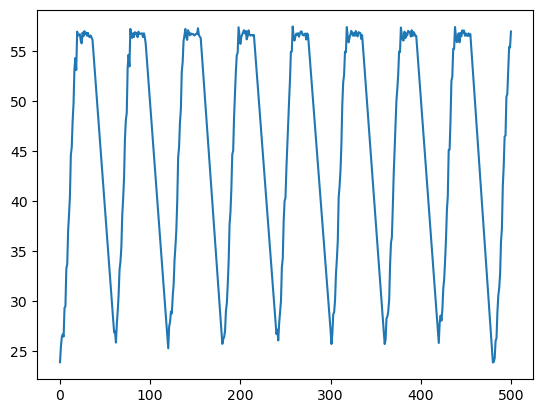

In [98]:
next_group = df1['interval_second'].shift(-1)
condition_met = (df1['interval_second'] == 5) & (df1['interval_second'].shift(-1) == 2)
df1['heat_round'] = condition_met.cumsum()
df1['heat_round']=df1['heat_round'].shift(1).fillna(0).astype(int)
df1['row_index'] = df1.groupby('heat_round').cumcount()
df1['stamp']=df1['heat_round']*60+df1['row_index']
df1["temp"]=df1["temp"]*10
df1_sub=df1[df1["stamp"]<=500]
plt.plot(df1_sub['stamp'], df1_sub['temp'])

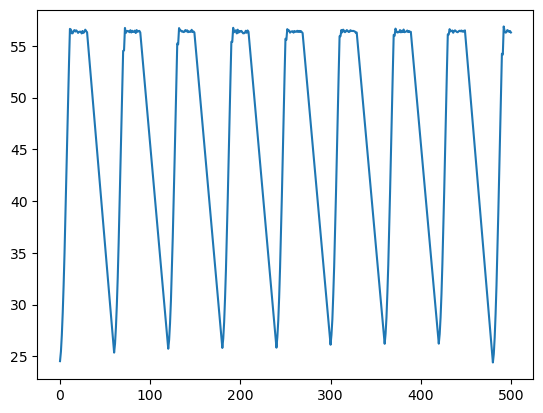

In [99]:
next_group = df2['interval_second'].shift(-1)
condition_met = (df2['interval_second'] == 5) & (df2['interval_second'].shift(-1) == 2)
df2['heat_round'] = condition_met.cumsum()
df2['heat_round']=df2['heat_round'].shift(1).fillna(0).astype(int)
df2['row_index'] = df2.groupby('heat_round').cumcount()
df2['stamp']=df2['heat_round']*60+df2['row_index']
df2["temp"]=df2["temp"]*10
df2_sub=df2[df2["stamp"]<=500]
plt.plot(df2_sub['stamp'], df2_sub['temp'])

In [62]:
import os
import pandas as pd
import json
from datetime import datetime
from pytz import timezone
import math
import numpy as np
import cv2

from PIL import ImageTk, Image
import shutil
import tifffile
import matplotlib.pyplot as plt
import copy


In [63]:
class scope_constant():
    piezo_focus_start_pos = -30
    piezo_focus_end_pos = 30
    piezo_step = 1.5

    scope_start_pos = -15
    scope_end_pos = 15
    scope_focus_end_pos = 30
    scope_focus_start_pos = -30
    scope_step = 1.5

    piezo_maxpro_start_pos = -15
    piezo_maxpro_end_pos = 15

    ZDrive_safe_pos = 500
    XYStage_fluidics_safe_pos = [-56900.7, -3062.1]
    XYStage_image_safe_pos = [44198.6, -4834.5]

    scope_exposure_time_dict = {"G": 220, "T": 150, "A": 100, "C": 100, "DIC": 10, "GFP": 100, "TxRed": 100, "DAPI": 50}
    stack_num_focus = round(abs(piezo_focus_end_pos - piezo_focus_start_pos) / piezo_step)
    stack_num_maxpro = round(abs(piezo_maxpro_start_pos - piezo_maxpro_end_pos) / piezo_step)

    sharpen1 = np.array(([0, 1, 0],
                         [-1, 5, -1],
                         [0, -1, 0]), dtype="int")
    stage_x_dir = -1;  # -1: left is larger
    stage_y_dir = 1;  # 1: bottom is larger
    pos_per_slice = 4;
    pixelsize =0.33
    imwidth =2048
    overlap = 10

def get_position_piezo(pos):
    position_name = pos['Device']['scalar']
    position_value = pos['Position_um']['array']
    if position_name == 'ZDrive':
        return {'z': position_value[0]}
    elif position_name == 'XYStage':
        return {'x': position_value[0], 'y': position_value[1]}
    elif position_name == 'DA Z Stage':
        return {'piezo': position_value[0]}
    else:
        pass
def ind2sub(array_shape, ind):
    # Gives repeated indices, replicates matlabs ind2sub
    cols = (ind.astype("int32") // array_shape[0])
    rows = (ind.astype("int32") % array_shape[0])
    return (rows, cols)
def get_pos_data(item):
    positions = item['DevicePositions']['array']
    pos_data = {}
    for pos in positions:
        pos_data.update(get_position_piezo(
            pos))  # change to get_position_piezo(pos) if have piezo, change to get_position(pos) if no piezo
    pos_data.update({'position': item['Label']['scalar']})
    return pos_data
def createtiles(df):
    tileconfig = [None] * (math.floor(len(df) / 4))
    lablelist = []
    poslist = []
    Slide = []
    number = []
    pos = []
    for i in range(0, math.floor(len(df) / 4)):
        y = df['y'][i * 4:(i + 1) * 4].to_numpy(dtype=float)
        x = df['x'][i * 4:(i + 1) * 4].to_numpy(dtype=float)
        z = df['z'][i * 4:(i + 1) * 4].to_numpy(dtype=float)

        # calculate midpoint xy
        midpointx = np.ptp(x) / 2 + np.min(x)
        midpointy = np.ptp(y) / 2 + np.min(y)
        # regress z slope and midpoint on xy
        a = np.array([x - midpointx, y - midpointy, np.ones(len(x))])
        z1 = np.linalg.lstsq(a.T, np.array([z]).T, rcond=None)[0]
        zslopex = z1[0];
        zslopey = z1[1];
        midpointz = z1[2];
        # calculate tile config
        tileconfig[i] = [math.ceil(np.ptp(x) / (
                scope_constant.imwidth * (1 - scope_constant.overlap / 100) * scope_constant.pixelsize)) + 1,
                         math.ceil(np.ptp(y) / (scope_constant.imwidth * (
                                 1 - scope_constant.overlap / 100) * scope_constant.pixelsize)) + 1]
        midpoint = [tileconfig[i][0] / 2 - 0.5, tileconfig[i][1] / 2 - 0.5]

        for n in range(0, tileconfig[i][0] * tileconfig[i][1]):
            grid_col, grid_row = ind2sub(tileconfig[i], np.array(n))
            # change LABEL
            LABEL = ['Pos' + str(i + 1) +
                     '_' + str(grid_col).zfill(3) +
                     '_' + str(grid_row).zfill(3)]
            # change XY positions
            Yoffset = (grid_row - midpoint[1]) * scope_constant.imwidth * (
                    1 - scope_constant.overlap / 100) * scope_constant.pixelsize;
            Xoffset = (grid_col - midpoint[0]) * scope_constant.imwidth * (
                    1 - scope_constant.overlap / 100) * scope_constant.pixelsize;
            Y = round(midpointy + Yoffset);
            X = round(midpointx + Xoffset);
            # find the device of XYstage
            Zoffset = Yoffset * zslopey + Xoffset * zslopex;
            Z = midpointz + Zoffset;
            poslist.append([X, Y, Z[0]])
            lablelist.append(LABEL[0])
            Slide.append('slide_' + str(i + 1))
            pos.append('Pos' + str(i + 1))
            number.append(n)

    tilepos = pd.DataFrame(columns=['Slidenum', 'Posinfo', 'X', 'Y', 'Z'])
    tilepos['Slidenum'] = Slide
    tilepos['Posinfo'] = lablelist
    tilepos['Pos'] = pos
    tilepos['X'] = [pos[0] for pos in poslist]
    tilepos['Y'] = [pos[1] for pos in poslist]
    tilepos['Z'] = [pos[2] for pos in poslist]
    return tilepos
def get_col(image_file_name):
    start = image_file_name.find('_', 7) + 1
    end = start + 3
    return int(image_file_name[start:end])


def get_row(image_file_name):
    start = image_file_name.find('_') + 1
    end = start + 3
    return int(image_file_name[start:end])
def fix_Posinfo(tilepos):
    tilepos_new = pd.DataFrame(columns=['Slidenum', 'Posinfo', 'X', 'Y', 'Z', 'Pos', 'switched_Posinfo'])
    slice_ls = pd.unique(tilepos['Pos'])
    for s in slice_ls:
        image_name_df = tilepos[tilepos['Pos'] == s]
        image_name = image_name_df['Posinfo']
        col_list = [get_col(i) for i in image_name]
        row_list = [get_row(i) for i in image_name]
        row_list_new = [str(i).zfill(3) for i in row_list]
        col_list_new = [str(max(col_list) - i).zfill(3) for i in col_list]
        new_name = []
        for num in range(len(row_list_new)):
            name = s + "_" + row_list_new[num] + "_" + col_list_new[num]
            new_name.append(name)
        image_name_df['switched_Posinfo'] = new_name
        frames = [tilepos_new, image_name_df]
        tilepos_new = pd.concat(frames)
        return tilepos_new
def create_scan_even(XY):
    event = []
    for i in range(XY.shape[0]):
        event.append({'axes': {'channel': 'DIC'},'config_group': ['Channel', 'DIC'],'exposure':10,'X':XY[i][0],'Y':XY[i][1]})
    return event

In [64]:
with open(os.path.join("D:\\","20241114_Dox_rabies_748972","cycle01.pos")) as f:
   slide1_coor = json.load(f)
df = pd.DataFrame([get_pos_data(item) for item in slide1_coor['map']['StagePositions']['array']])[
    ['position', 'x', 'y', 'z', 'piezo']]
tiles = createtiles(df)

In [65]:
tiles2 = fix_Posinfo(tiles)

C:\Users\barscope2\AppData\Local\Temp\ipykernel_29460\325879021.py:139: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  image_name_df['switched_Posinfo'] = new_name


In [66]:
tiles2

,Slidenum,Posinfo,X,Y,Z,Pos,switched_Posinfo
0,slide_1,Pos1_000_000,-49970,9722,3502.944647,Pos1,Pos1_000_010
1,slide_1,Pos1_001_000,-49361,9722,3502.944738,Pos1,Pos1_001_010
2,slide_1,Pos1_002_000,-48753,9722,3502.944829,Pos1,Pos1_002_010
3,slide_1,Pos1_003_000,-48145,9722,3502.944920,Pos1,Pos1_003_010
4,slide_1,Pos1_004_000,-47537,9722,3502.945011,Pos1,Pos1_004_010
...,...,...,...,...,...,...,...
182,slide_1,Pos1_012_010,-42671,15805,3502.925652,Pos1,Pos1_012_000
183,slide_1,Pos1_013_010,-42062,15805,3502.925743,Pos1,Pos1_013_000
184,slide_1,Pos1_014_010,-41454,15805,3502.925833,Pos1,Pos1_014_000
185,slide_1,Pos1_015_010,-40846,15805,3502.925924,Pos1,Pos1_015_000


In [67]:
tiles2['pos'] = 'pos' + tiles2.index.astype(str)

In [68]:
tiles2=tiles2[["X","Y","Z","pos","switched_Posinfo"]]

In [71]:
tiles2.to_csv(os.path.join("device", "tissue_scanner", "tile.csv"),index=False)

In [47]:
with open(os.path.join("device", "tissue_scanner", "template.pos")) as f:
    temp = json.load(f)

In [48]:
temp_coor = temp['map']['StagePositions']['array'][0]
temp['map']['StagePositions']['array'] = copy.deepcopy([])

In [49]:
temp

{'encoding': 'UTF-8',
 'format': 'Micro-Manager Property Map',
 'major_version': 2,
 'minor_version': 0,
 'map': {'StagePositions': {'type': 'PROPERTY_MAP', 'array': []}}}

In [50]:
for i in range(len(tiles2)):
    temp_coor['DevicePositions']['array'][2]['Position_um']['array'] = copy.deepcopy(
        [int(tiles2.iloc[i, 0]), int(tiles2.iloc[i, 1])])
    temp_coor['Label']['scalar'] = copy.deepcopy('Pos' + str(i))
    temp['map']['StagePositions']['array'].append(copy.deepcopy(temp_coor))
json_object = json.dumps(temp, indent=2)
# with open(os.path.join(self.path, "auto.pos"), "w") as outfile:
#     outfile.write(json_object)

In [51]:
with open(os.path.join("D:\\","20241114_Dox_rabies_748972", "tiles.pos"), "w") as outfile:
    outfile.write(json_object)

In [72]:
import json
with open(os.path.join("config_file", "Heat_stage.json"), 'r') as r:
    heater_cfg = json.load(r)
    
dict={'heatstage1': 'slide1', 'heatstage2': 'slide2', '': 'slide3'}

In [82]:
list(dict.keys())

['heatstage1', 'heatstage2', '']

In [73]:
heater_cfg

[{'heat_stage': 'heatstage1',
  'do_port': 'port1',
  'do_line': 'line0',
  'ai_line': 'ai0',
  'DAQ': 'Dev3'},
 {'heat_stage': 'heatstage2',
  'do_port': 'port1',
  'do_line': 'line1',
  'ai_line': 'ai1',
  'DAQ': 'Dev3'},
 {'heat_stage': 'heatstage3',
  'do_port': 'port1',
  'do_line': 'line2',
  'ai_line': 'ai3',
  'DAQ': 'Dev3'}]

In [83]:
[i for i in heater_cfg if i['heat_stage'] in list(dict.keys())]

[{'heat_stage': 'heatstage1',
  'do_port': 'port1',
  'do_line': 'line0',
  'ai_line': 'ai0',
  'DAQ': 'Dev3'},
 {'heat_stage': 'heatstage2',
  'do_port': 'port1',
  'do_line': 'line1',
  'ai_line': 'ai1',
  'DAQ': 'Dev3'}]

In [80]:
heater_cfg[0]['heat_stage']

'heatstage1'

In [1]:
import serial
import math
import sys
import os
sys.path.append(os.path.join("D:/","repos","Seq_o_matics","driver","elveflow_mux_12valve_2025","DLL64"))#add the path of the library here
sys.path.append(os.path.join("D:/","repos","Seq_o_matics","driver","elveflow_mux_12valve_2025"))#add the path of the LoadElveflow.py
from ctypes import *
from array import array
from Elveflow64 import *

In [2]:
Instr_ID=c_int32(0)
print("MUX DRI ID: %d" % Instr_ID.value)

MUX DRI ID: 0


In [20]:
error=MUX_DRI_Initialization("ASRL19::INSTR".encode('ascii'),byref(Instr_ID)) 
print('error:%d' % error)

error:0


In [4]:
valve=c_int32(-1)
error=MUX_DRI_Get_Valve(Instr_ID.value,byref(valve)) #get the active valve. it returns 0 if valve is busy.
print('selected channel',valve.value)

selected channel 1


In [21]:
valve2=c_double()
Valve2=6 #refer to SDK User Guide for valve selection depending on your instrument
Valve2=int(Valve2)#convert to int
Valve2=c_int32(Valve2)#convert to c_int32
error=MUX_DRI_Set_Valve(Instr_ID.value,Valve2,0) 
print('error:%d' % error)

error:0


In [7]:
error

0

In [19]:
MUX_DRI_Destructor(Instr_ID)

0